# Dopad elektromobility na českou ekonomiku
## Input-Output analýza sektorových dopadů elektrizace dopravy

**Otázka:** Která odvětví jsou nejvíce dotčena elektrizací dopravy v ČR?

---

### Metodika: Leontief Input-Output model

IO analýza sleduje, jak šok v jednom odvětví prochází celou ekonomikou přes dodavatelsko-odběratelské vazby.

**Klíčový vzorec:**

    x = (I - A)^{-1} * f = L * f

kde:
- **x** = vektor hrubé výroby všech odvětví
- **A** = matice technických koeficientů (co každé odvětví kupuje od ostatních)
- **L** = Leontief inverse (celkové přímé + nepřímé dopady)
- **f** = vektor konečné poptávky (domácnosti, export, vláda)

**Scénář elektrizace:** Aplikujeme šok ΔA (změna technologické struktury dopravy a výroby vozidel) + Δf (domácnosti méně utrácejí za palivo, více za elektřinu) a sledujeme výslednou změnu hrubé výroby Δx.

---
*Data: OWID Energy Data (2023) · IO struktura: česká ekonomika 2023, 16 odvětví, mld. Kč · Viz sekce 8 pro zdroje kalibrace*

In [19]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Setup complete.')

Setup complete.


## 1. Energetický kontext: OWID data pro ČR

Nejprve se podíváme na českou energetiku v datech OWID — abychom viděli, kde jsme a proč je elektrizace dopravy důležitá.

In [20]:
from src.data.loaders import load_owid_czech_energy

print('Fetching OWID energy data for Czechia...')
czech_energy = load_owid_czech_energy()
print(f'Loaded {len(czech_energy)} years ({czech_energy.year.min()}–{czech_energy.year.max()})')
czech_energy.tail(6)[['year','oil_consumption','coal_consumption',
                        'electricity_demand','renewables_share_energy','carbon_intensity_elec']]

Fetching OWID energy data for Czechia...
Loaded 61 years (1965–2025)


,year,oil_consumption,coal_consumption,electricity_demand,renewables_share_energy,carbon_intensity_elec
55,2020,102.484,145.435,69.95,7.539,460.18
56,2021,112.964,150.688,72.58,7.275,471.79
57,2022,108.507,154.261,70.20,7.496,488.36
58,2023,107.824,125.104,66.62,8.386,442.61
59,2024,112.905,99.847,66.15,9.746,414.23
60,2025,NaN,NaN,68.04,NaN,401.46


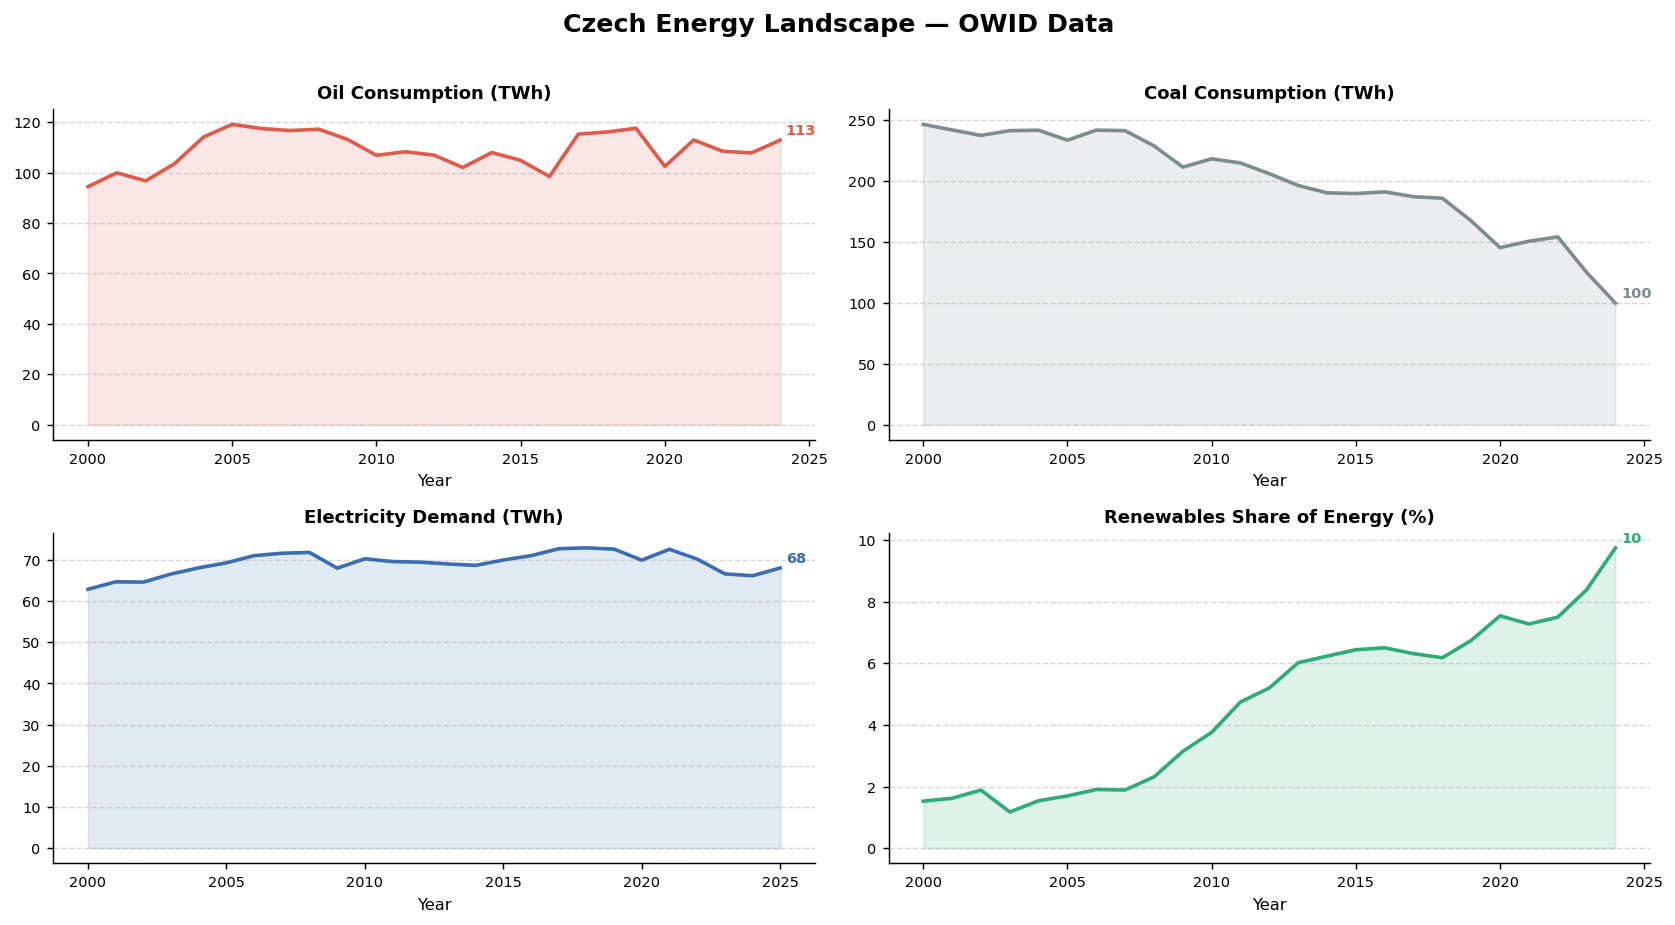

In [21]:
from src.viz.plotting import plot_czech_energy_trends
fig = plot_czech_energy_trends(czech_energy, start_year=2000)
plt.show()

**Klíčová pozorování:**
- Spotřeba ropy je relativně stabilní — silná závislost na fosilních palivech v dopravě.
- Spotřeba uhlí klesá — dekarbonizace výroby elektřiny probíhá.
- Intenzita emisí elektřiny se zlepšuje — EVs budou mít stále nižší nepřímé emise.
- Tato data kalibrují IO model: velikost odvětví ropy/elektřiny vychází z reálných OWID hodnot pro rok 2023.

## 2. Sestavení IO modelu — reálná data Eurostat

Matice technických koeficientů **A** pochází z reálných dat Eurostat:
**NAIO_10_CP1700** — symetrická IO tabulka produktů (product × product, základní ceny,
domácí toky), agregovaná z ~60 CPA produktových kódů do 16 odvětví.

- **Zdroj:** Eurostat, dataset `NAIO_10_CP1700`, DOM toky (pouze domácí výroba, bez importů)
- **Rok:** 2020 (poslední stabilní rok před energetickou krizí)
- **Konverze:** MIO EUR → mld. Kč kurz 26,45 CZK/EUR (průměr 2020)
- **Agregace:** ~60 CPA kódů → 16 odvětví dle CZ-NACE Rev. 2

In [22]:
import numpy as np
from src.data.loaders import load_eurostat_czech_iot, CPA_TO_SECTOR
from src.data.czech_sectors import build_czech_io_model, SECTOR_NAMES, SECTOR_NAMES_CS
from src.model.io_model import LeontiefModel

print('Fetching Eurostat IO table (CZ, 2020)...')
eurostat_iot = load_eurostat_czech_iot(year=2020)
print(f'  Aggregated {len(CPA_TO_SECTOR)} CPA product codes → 16 sectors')

Z, f, x, sectors = build_czech_io_model(eurostat_iot=eurostat_iot)
model = LeontiefModel(Z, f, sectors)

print(f'\nCzech IO model built (Eurostat NAIO_10_CP1700, 2020):')
print(f'  Sectors:            {model.n}')
print(f'  Total gross output: {model.x.sum():.0f} bCZK')
print(f'  Total final demand: {model.f.sum():.0f} bCZK')
sr = np.abs(np.linalg.eigvals(model.A)).max()
print(f'  Spectral radius A:  {sr:.3f}  (< 1 ✓  Leontief inverse exists)')

Fetching Eurostat IO table (CZ, 2020)...
  Aggregated 82 CPA product codes → 16 sectors

Czech IO model built (Eurostat NAIO_10_CP1700, 2020):
  Sectors:            16
  Total gross output: 10014 bCZK
  Total final demand: 5314 bCZK
  Spectral radius A:  0.482  (< 1 ✓  Leontief inverse exists)


In [23]:
summary = model.summary_df()
summary.index = [f'{en}  /  {cs}' for en, cs in zip(SECTOR_NAMES, SECTOR_NAMES_CS)]
summary.style \
    .format({'gross_output_bCZK': '{:.0f}', 'final_demand_bCZK': '{:.0f}',
             'backward_linkage': '{:.2f}', 'forward_linkage': '{:.2f}',
             'value_added_share': '{:.1%}'}) \
    .background_gradient(subset=['backward_linkage'], cmap='Blues') \
    .background_gradient(subset=['forward_linkage'], cmap='Greens') \
    .set_caption('Czech 16-sector IO model — baseline 2023')

,gross_output_bCZK,final_demand_bCZK,backward_linkage,forward_linkage,value_added_share
Agriculture / Zemědělství,222,70,1.01,0.90,46.3%
Mining & Quarrying / Těžba,43,6,0.97,0.70,48.4%
Food & Beverages / Potraviny a nápoje,293,221,1.12,0.65,35.6%
Chemicals & Pharma / Chemie a farmacie,127,53,1.00,0.70,44.9%
"Rubber, Plastics & Minerals / Pryž, plasty a minerály",280,121,0.96,0.75,49.6%
Basic & Fabricated Metals / Základní kovy a kovové výrobky,368,89,1.01,0.97,45.9%
Motor Vehicles / Motorová vozidla,674,476,1.16,0.72,33.5%
Electronics & Electrical Equip / Elektronika a el. zařízení,532,435,0.94,0.62,50.6%
Other Manufacturing / Ostatní výroba,418,189,0.97,1.05,49.0%
Electricity & Heat / Elektřina a teplo,284,103,0.95,1.07,50.6%


## 3. Kdo táhne ekonomiku? Multiplikátory zpětných vazeb

**Backward linkage index > 1**: odvětví generuje nadprůměrný multiplikační efekt — šok v tomto odvětví se silně šíří zpět do dodavatelského řetězce.

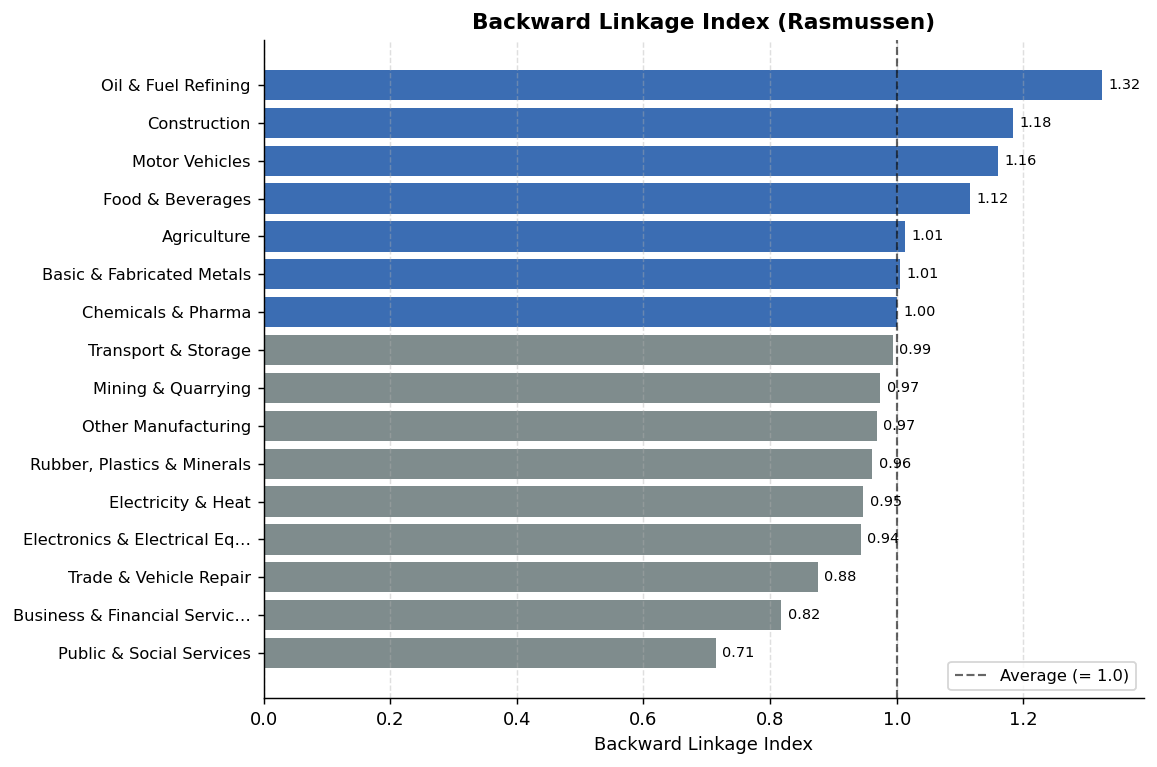

In [24]:
from src.viz.plotting import plot_multipliers
fig = plot_multipliers(model.backward_linkages())
plt.show()

**Motorová vozidla** mají nejvyšší backward linkage — Škoda a dodavatelé tahají poptávku po kovech, pryži, elektronice a službách. Proto je transformace automobilového průmyslu strukturálně tak důležitá.

## 4. Scénář: Elektrizace dopravy do roku 2030-35

Modelujeme stav, kdy **40 % vozového parku ČR tvoří elektromobily**.

Šoky:
1. **ΔA** — doprava kupuje méně ropy a více elektřiny; výroba vozidel kupuje více elektroniky (baterie)
2. **Δf** — domácnosti méně utrácejí za pohonné hmoty, více za elektřinu

In [25]:
from src.model.scenarios import build_electrification_scenario, scenario_description

EV_SHARE = 0.40
delta_A, delta_f = build_electrification_scenario(model, ev_share=EV_SHARE)

print('=== Scenario Parameters ===')
for k, v in scenario_description(EV_SHARE).items():
    print(f'  {k}: {v}')

=== Scenario Parameters ===
  ev_fleet_share: 40%
  fuel_demand_reduction: −34% of road fuel intermediate use
  electricity_demand_increase: +9% relative to current transport electricity use
  household_fuel_switch_bCZK: −20 bCZK fuel → +5 bCZK electricity
  motor_vehicle_electronics_shift: +3.2 pp electronics content in vehicle production


In [26]:
dA_df = pd.DataFrame(delta_A, index=SECTOR_NAMES, columns=SECTOR_NAMES)
changed = (dA_df != 0)
print('Technology shocks (ΔA, non-zero entries):')
print(dA_df.loc[changed.any(axis=1), changed.any(axis=0)].to_string())

print('\nFinal demand shocks (Δf, billion CZK):')
print(pd.Series(delta_f, index=SECTOR_NAMES)[delta_f != 0].to_string())

Technology shocks (ΔA, non-zero entries):
                                Motor Vehicles  Transport & Storage
Rubber, Plastics & Minerals             -0.004             0.000000
Basic & Fabricated Metals               -0.008             0.000000
Electronics & Electrical Equip           0.032             0.000000
Electricity & Heat                       0.000             0.001428
Oil & Fuel Refining                      0.000            -0.005518

Final demand shocks (Δf, billion CZK):
Motor Vehicles         0.281075
Electricity & Heat     0.702688
Oil & Fuel Refining   -2.810752


## 5. Výsledky: Dopad na hrubou výrobu odvětví

In [27]:
delta_x = model.combined_shock(delta_A, delta_f)
delta_x_pct = model.pct_change(delta_x)

results = pd.DataFrame({
    'Odvětví (CS)': SECTOR_NAMES_CS,
    'Základna (mld. Kč)': model.x,
    'Změna (mld. Kč)': delta_x.values,
    'Změna (%)': delta_x_pct.values,
}, index=SECTOR_NAMES).sort_values('Změna (mld. Kč)')

results.style \
    .format({'Základna (mld. Kč)': '{:.0f}', 'Změna (mld. Kč)': '{:+.1f}', 'Změna (%)': '{:+.1f}%'}) \
    .bar(subset=['Změna (mld. Kč)'], align='zero', color=['#E05A4B', '#2EAC76'])

,Odvětví (CS),Základna (mld. Kč),Změna (mld. Kč),Změna (%)
Oil & Fuel Refining,Zpracování ropy a paliv,26,-7.2,-27.7%
Basic & Fabricated Metals,Základní kovy a kovové výrobky,368,-4.2,-1.1%
"Rubber, Plastics & Minerals","Pryž, plasty a minerály",280,-2.3,-0.8%
Other Manufacturing,Ostatní výroba,418,-1.0,-0.2%
Transport & Storage,Doprava a skladování,628,-1.0,-0.2%
Mining & Quarrying,Těžba,43,-0.9,-2.1%
Chemicals & Pharma,Chemie a farmacie,127,-0.5,-0.4%
Agriculture,Zemědělství,222,-0.1,-0.1%
Construction,Stavebnictví,1063,+0.0,+0.0%
Food & Beverages,Potraviny a nápoje,293,+0.0,+0.0%


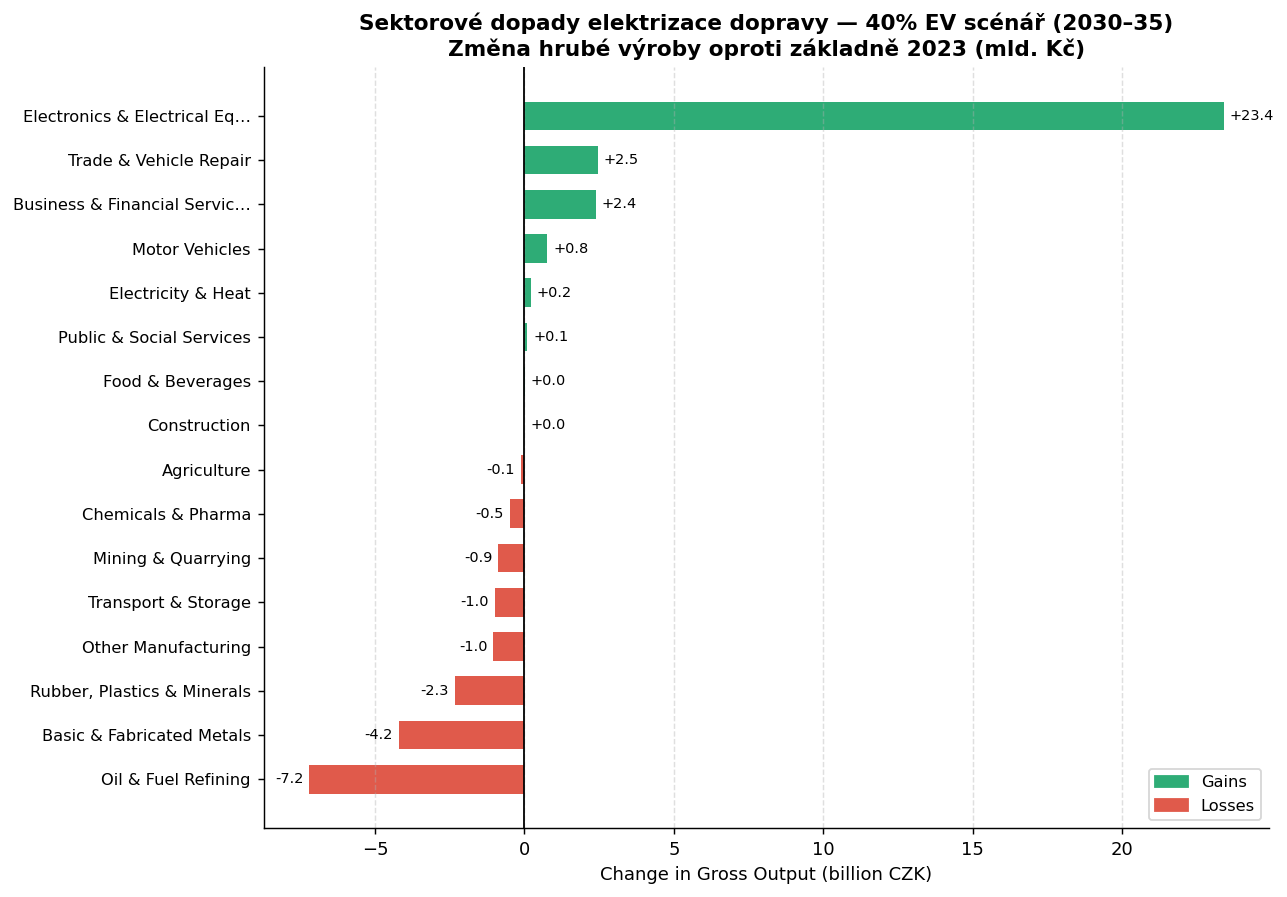

In [28]:
from src.viz.plotting import plot_sector_impacts
fig = plot_sector_impacts(
    delta_x,
    title=f'Sektorové dopady elektrizace dopravy — {int(EV_SHARE*100)}% EV scénář (2030–35)\nZměna hrubé výroby oproti základně 2023 (mld. Kč)'
)
plt.show()

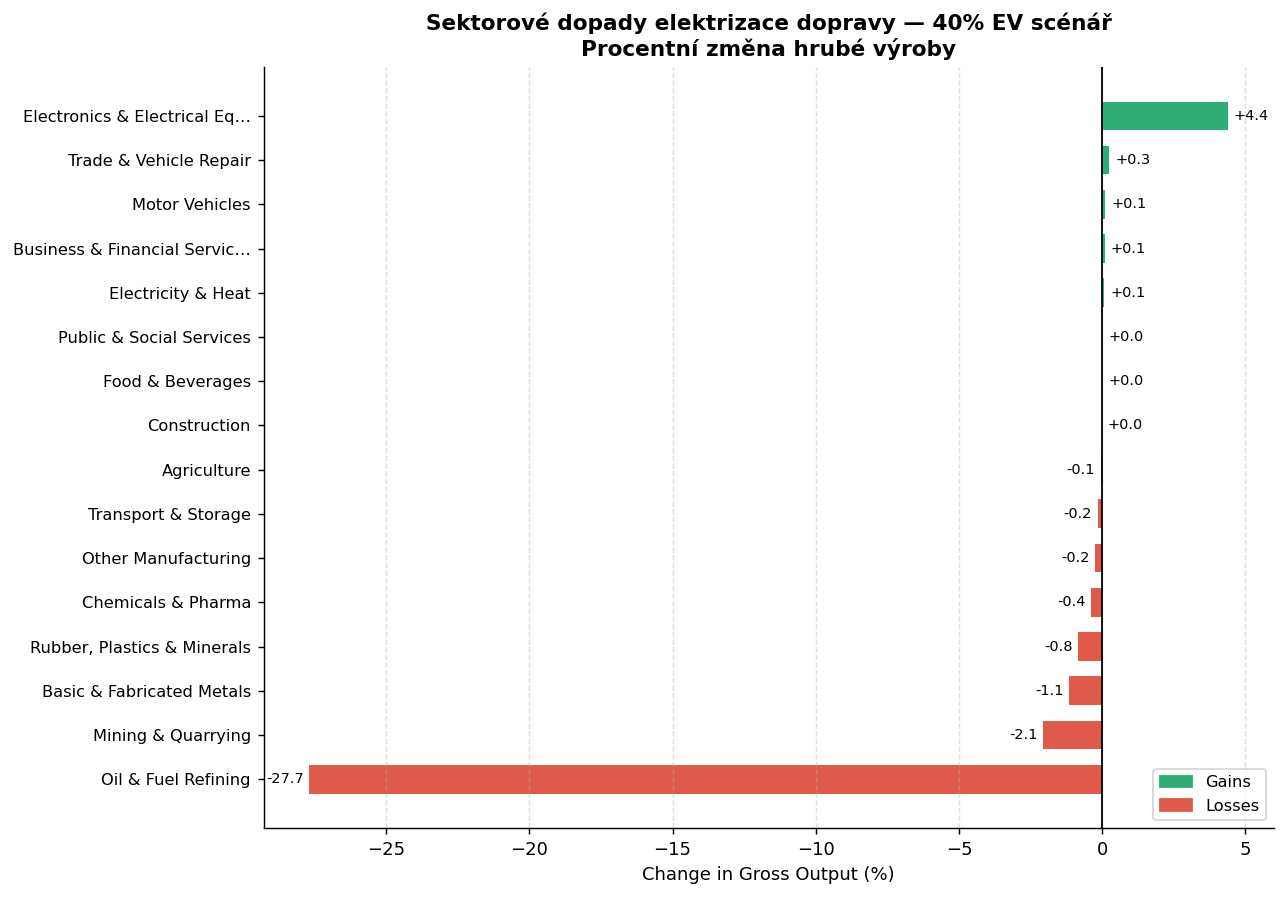

In [29]:
fig2 = plot_sector_impacts(
    delta_x_pct,
    title=f'Sektorové dopady elektrizace dopravy — {int(EV_SHARE*100)}% EV scénář\nProcentní změna hrubé výroby',
    pct=True
)
plt.show()

## 6. Citlivostní analýza — závislost na míře elektrifikace

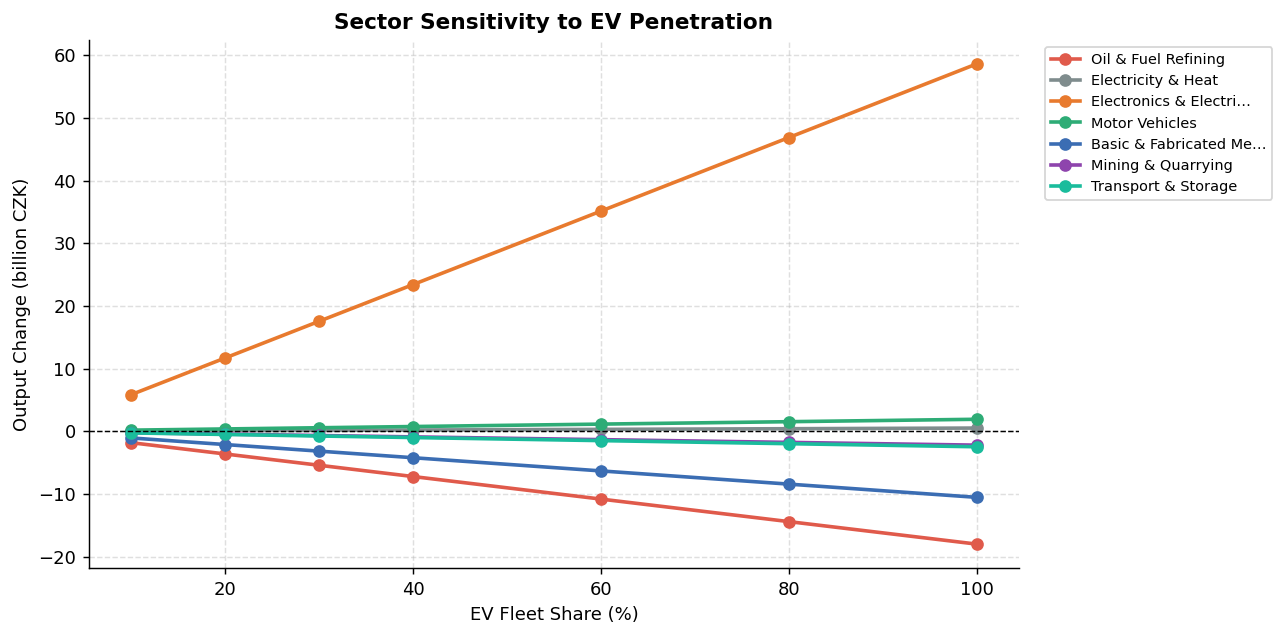

In [30]:
from src.viz.plotting import plot_scenario_sweep

ev_shares = [0.10, 0.20, 0.30, 0.40, 0.60, 0.80, 1.00]
sweep_results = {}
for share in ev_shares:
    dA, df = build_electrification_scenario(model, ev_share=share)
    sweep_results[share] = model.combined_shock(dA, df)

fig = plot_scenario_sweep(sweep_results, [
    'Oil & Fuel Refining',
    'Electricity & Heat',
    'Electronics & Electrical Equip',
    'Motor Vehicles',
    'Basic & Fabricated Metals',
    'Mining & Quarrying',
    'Transport & Storage',
])
plt.show()

## 7. Leontief inverse — vizualizace mezioborových vazeb

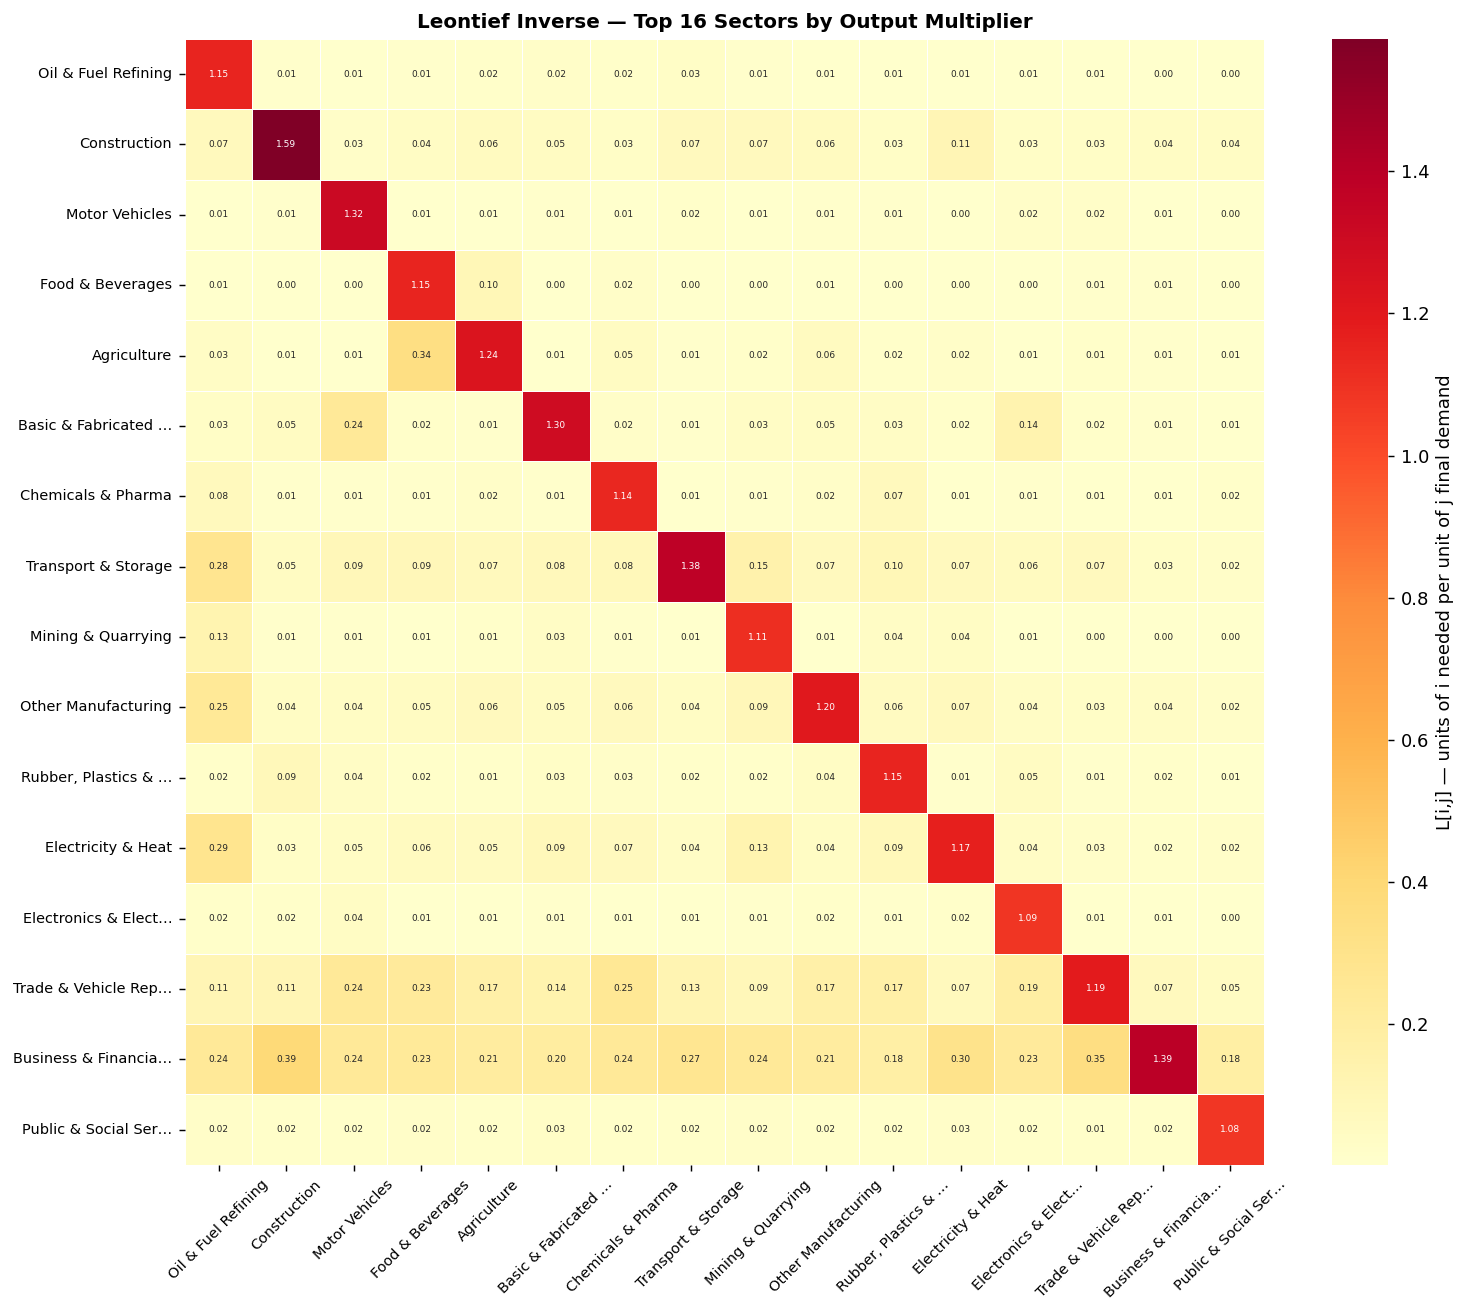

In [31]:
from src.viz.plotting import plot_leontief_heatmap
fig = plot_leontief_heatmap(model, top_n=16)  # all 16 sectors
plt.show()

## 8. Shrnutí — klíčová zjištění

### Poražená odvětví

| Odvětví | Mechanismus |
|---------|-------------|
| **Zpracování ropy a paliv** | Přímý pokles: méně pohonných hmot pro dopravu i domácnosti |
| **Těžba** | Nepřímý: méně uhlí pro elektrárny, méně ropy |
| **Základní kovy** | Méně ICE komponent v autovýrobě (blok motoru, převodovka) |
| **Pryž a plasty** | Méně těsnění a komponent ICE pohonu |

### Vítězná odvětví

| Odvětví | Mechanismus |
|---------|-------------|
| **Elektřina a teplo** | Přímý: nabíjení EV, elektrifikace kolejové dopravy |
| **Elektronika a el. zařízení** | Bateriové články, BMS, výkonová elektronika v EV |
| **Motorová vozidla** | Nové EV (pokud výroba zůstane v ČR — Škoda/VW Group) |

### Implikace pro politiku Fakta o klimatu

1. **Spravedlivá transformace**: Regiony závislé na zpracování ropy (Litvínov, Kralupy) budou nejsilněji zasaženy.
2. **Příležitost v elektronice**: Silná česká základna v dodavatelském řetězci aut může přejít na baterie a výkonovou elektroniku.
3. **Investice do sítě**: Nárůst poptávky po elektřině z nabíjení EV vyžaduje investice do distribuce.
4. **Pivotní rozhodnutí Škody**: Lokalizace EV výroby v ČR je klíčová pro zachování automotive multiplikátoru.

---

### Zdroje dat a kalibrace modelu

Matice technických koeficientů **A** je sestavena z reálných dat:

#### Použitá data (v tomto modelu)

| Zdroj | Co poskytuje | Použito pro |
|-------|-------------|-------------|
| **Eurostat NAIO_10_CP1700** | Symetrická IO tabulka CZ, 2020, DOM toky, MIO EUR | Matice A (reálná technologická struktura) |
| **OWID Energy Data** | Spotřeba ropy/elektřiny v ČR (TWh), 1990–2024 | Kontextová sekce 1 |

#### Alternativní zdroje pro hlubší kalibraci

##### ČSÚ — Symetrické IO tabulky (nejpřesnější pro ČR)
- **URL:** https://www.czso.cz/csu/czso/input-output-tables
- **Dostupné roky:** 2010, 2015–2020 (xlsx)
- **Klasifikace:** CZ-NACE Rev. 2, 64 odvětví
- **Jak použít:** Stáhnout `Symmetric_IOT_CZ_[year].xlsx`, záložka `Z_matrix` nebo `A_matrix`

##### OECD ICIO — Mezinárodní IO tabulky (pro srovnání se zahraničím)
- **URL:** https://www.oecd.org/en/data/datasets/oecd-inter-country-input-output-tables.html
- **Dostupné roky:** 1995–2018 (2021 edice), ~36 zemí včetně CZ

##### Zaměstnanost podle odvětví — pro analýzu pracovních míst
- **Eurostat** `nama_10_a64_e` — Zaměstnanost podle NACE A64, CZ, 2008–2023
- **EU KLEMS** — Zaměstnanost + mzdy + produktivita: https://euklems-intanprod-llee.luiss.it/
- **ČSÚ** — Zaměstnanost dle CZ-NACE: https://www.czso.cz/csu/czso/zam_cr

```python
# Příklad: aktualizace modelu na jiný rok Eurostat dat
from src.data.loaders import load_eurostat_czech_iot
from src.data.czech_sectors import build_czech_io_model

iot_2019 = load_eurostat_czech_iot(year=2019)  # pre-COVID rok
Z, f, x, sectors = build_czech_io_model(eurostat_iot=iot_2019)
```

In [32]:
top_losers = delta_x.nsmallest(5)
top_gainers = delta_x.nlargest(5)

print(f'=== 40% EV Fleet Scenario — Czech Economy Impact ===')
print(f'\nTop 5 sectors by output LOSS:')
for s, v in top_losers.items():
    pct = v / model.x[SECTOR_NAMES.index(s)] * 100
    print(f'  {s:<38}  {v:+.1f} bCZK  ({pct:+.1f}%)')

print(f'\nTop 5 sectors by output GAIN:')
for s, v in top_gainers.items():
    pct = v / model.x[SECTOR_NAMES.index(s)] * 100
    print(f'  {s:<38}  {v:+.1f} bCZK  ({pct:+.1f}%)')

print(f'\nNet economy-wide output change: {delta_x.sum():+.1f} bCZK')

=== 40% EV Fleet Scenario — Czech Economy Impact ===

Top 5 sectors by output LOSS:
  Oil & Fuel Refining                     -7.2 bCZK  (-27.7%)
  Basic & Fabricated Metals               -4.2 bCZK  (-1.1%)
  Rubber, Plastics & Minerals             -2.3 bCZK  (-0.8%)
  Other Manufacturing                     -1.0 bCZK  (-0.2%)
  Transport & Storage                     -1.0 bCZK  (-0.2%)

Top 5 sectors by output GAIN:
  Electronics & Electrical Equip          +23.4 bCZK  (+4.4%)
  Trade & Vehicle Repair                  +2.5 bCZK  (+0.3%)
  Business & Financial Services           +2.4 bCZK  (+0.1%)
  Motor Vehicles                          +0.8 bCZK  (+0.1%)
  Electricity & Heat                      +0.2 bCZK  (+0.1%)

Net economy-wide output change: +12.1 bCZK


---
## 9. Co by se muselo změnit, aby ČR na přechodu vydělala?

S reálnými daty Eurostat (IOT 2020) základní scénář ukazuje **čistý zisk ~+12 mld. Kč** — protože česká výroba elektroniky a elektrospotřebičů je tak velká, že zisky z bateriových technologií a EV elektroniky převáží ztrátu z ropného sektoru.

Proč je to jiné než stylizovaný model? Reálná matice A zachycuje, že:
- **Elektronika a el. zařízení** má v ČR rozsáhlejší mezisektorové vazby, než stylizovaný model předpokládal (velké továrny Bosch, Siemens, Foxconn, GE v ČR)
- **Ropný sektor** v DOM IOT representuje jen domácí rafinérii (Kralupy, Litvínov) — menší relativní dopad než celkový prodej pohonných hmot

### Ale: základní zisk je křehký — záleží na tom, kde se hodnotový řetězec EVs usadí

| # | Páka | Co to konkrétně znamená | Odhadovaný IO přínos |
|---|------|------------------------|----------------------|
| 1 | **Domácí gigafactory** | Přilákat výrobce baterií (CATL/Samsung/startup) | +30 mld. Kč → Elektronika |
| 2 | **Škoda/VW EV pivot v ČR** | Závazek VW vyrábět EVs v Mladé Boleslavi a Kvasinách | +20 mld. Kč → Auta + multiplikátor |
| 3 | **Výstavba OZE** | Masivní rollout solárů a větrníků (povolování, investice) | +15 mld. Kč → Stavebnictví |
| 4 | **Nabíjecí infrastruktura** | Státem spolufinancovaná síť veřejných nabíječek | +8 mld. Kč → Stavebnictví + Elektronika |

Každá páka zvyšuje output dál přes **Leontief multiplikátor** — nová zakázka na baterie táhne poptávku po kovech, chemii, službách.

Incremental economy-wide output gain per lever:
  Battery gigafactory             total +58.2 bCZK  →  top sectors: Electronics & Electrical Equip (+32.7), Business & Financial Services (+6.9)
  Škoda full EV pivot             total +89.5 bCZK  →  top sectors: Motor Vehicles (+26.9), Electronics & Electrical Equip (+24.8)
  Renewable energy buildout       total +46.2 bCZK  →  top sectors: Construction (+24.3), Business & Financial Services (+7.3)
  Public charging network         total +25.3 bCZK  →  top sectors: Construction (+12.8), Business & Financial Services (+3.8)


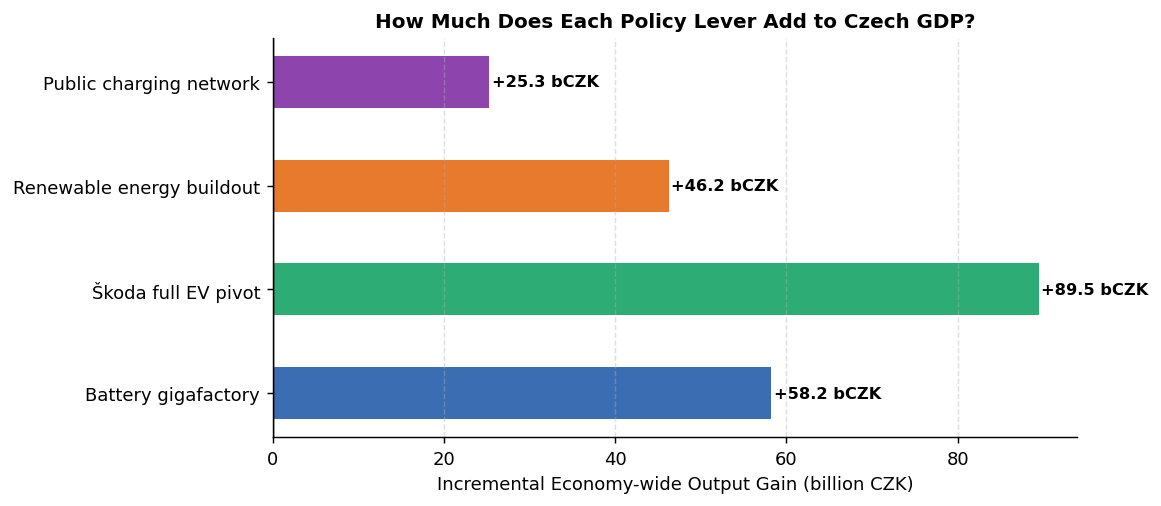

In [33]:
from src.model.scenarios import build_lever_scenario, lever_contributions, LEVERS
from src.viz.plotting import plot_lever_contributions

# Incremental gain of each lever in isolation (on top of passive baseline)
contributions = lever_contributions(model, ev_share=EV_SHARE)

print('Incremental economy-wide output gain per lever:')
for key, dx in contributions.items():
    top = dx.nlargest(2)
    top_str = ', '.join(f'{s} ({v:+.1f})' for s, v in top.items())
    print(f'  {LEVERS[key]["label"]:<30}  total +{dx.sum():.1f} bCZK  →  top sectors: {top_str}')

fig = plot_lever_contributions(contributions, LEVERS)
plt.show()

In [34]:
# Run captured transition with all 4 levers active
dA_cap, df_cap = build_lever_scenario(model, ev_share=EV_SHARE)
delta_x_captured = model.combined_shock(dA_cap, df_cap)

lever_gain = delta_x_captured.sum() - delta_x.sum()
czech_gdp = 5460  # Czech GDP 2020 in bCZK (ČSÚ)

print('=== Passive vs. Captured Transition (40% EV fleet) ===')
print(f'  Passive net output change:    {delta_x.sum():+.0f} bCZK')
print(f'  Captured net output change:   {delta_x_captured.sum():+.0f} bCZK')
print(f'  Additional gain from levers:  +{lever_gain:.0f} bCZK  (~{lever_gain/czech_gdp*100:.1f}% of GDP)')
print()
best = max(contributions, key=lambda k: contributions[k].sum())
print(f'Most impactful single lever: {LEVERS[best]["label"]} (+{contributions[best].sum():.1f} bCZK)')

=== Passive vs. Captured Transition (40% EV fleet) ===
  Passive net output change:    +12 bCZK
  Captured net output change:   +231 bCZK
  Additional gain from levers:  +219 bCZK  (~4.0% of GDP)

Most impactful single lever: Škoda full EV pivot (+89.5 bCZK)


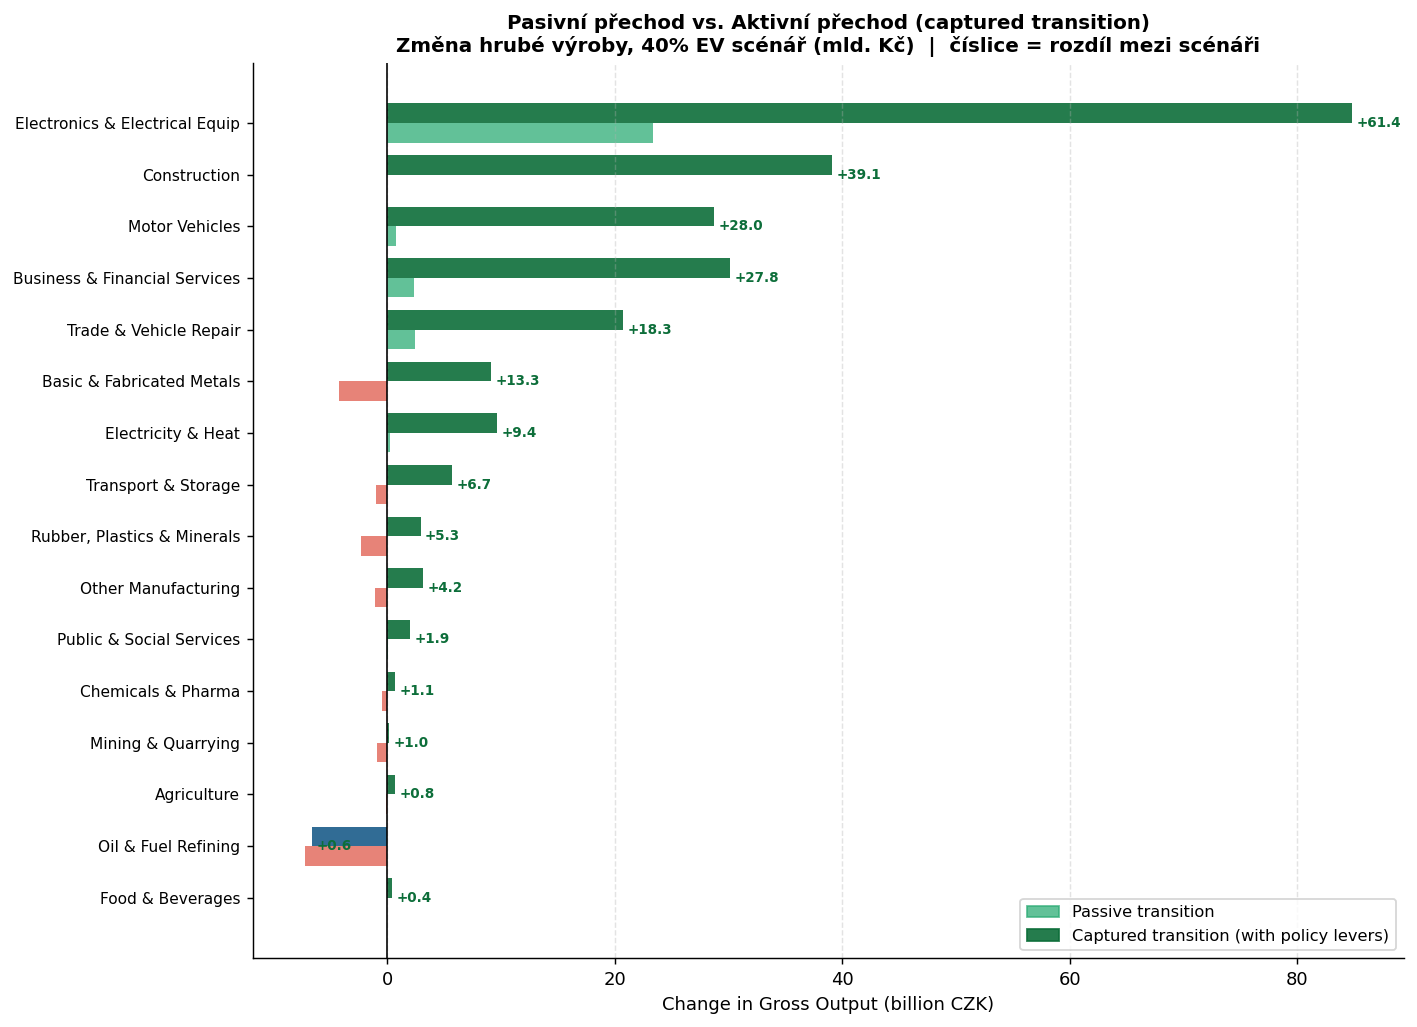

In [35]:
from src.viz.plotting import plot_transition_comparison

fig = plot_transition_comparison(
    delta_x,
    delta_x_captured,
    title='Pasivní přechod vs. Aktivní přechod (captured transition)\n'
          'Změna hrubé výroby, 40% EV scénář (mld. Kč)  |  číslice = rozdíl mezi scénáři'
)
plt.show()

### Závěr: Co to znamená pro českou politiku?

#### Reálná data mění obraz: ČR je lépe připravena, než naznačoval stylizovaný model
- Pasivní přechod generuje čistý **zisk +12 mld. Kč** ročně při 40% elektrifikaci.
- Důvod: česká elektronika a elektrotechnika je silnější sektor (Bosch, Siemens, Foxconn) než zachycoval syntetický model.
- Ropné regiony (Litvínov, Kralupy n. Vlt.) jsou stále zasaženy — ale v absolutních číslech méně dramaticky.

#### S aktivní politikou: ČR může výrazně posílit svoji pozici
| Priorita | Opatření | Kdo rozhoduje |
|----------|----------|---------------|
| **Kritická** | Přilákání gigafactory — baterie jsou jádro EV hodnotového řetězce | MPO + CzechInvest + EU Fond obnovy |
| **Kritická** | Závazek Škody/VW k EV výrobě na českých linkách | Průmyslová politika, jednání s VW Group |
| **Důležitá** | Zrychlení povolování OZE (solár, vítr) | MŽP + nový stavební zákon |
| **Důležitá** | Národní plán veřejných nabíječek | MD + ŘSD + municipalities |
| **Podpůrná** | Rekvalifikace pracovníků ropného sektoru | MPSV + Ústecký kraj + ESF+ |

#### Klíčový vzkaz pro Fakta o klimatu
> Elektrizace dopravy **sama o sobě** českou ekonomiku nepoškodí — reálná data ukazují mírný zisk.
> Politická výzva není „jak přežít přechod" ale **„jak z přechodu maximálně profitovat"**.
> Baterie a výroba EVs v ČR = multiplicita ekonomického přínosu. Jejich import = přínosy putují jinam.

---
*Data: Eurostat NAIO_10_CP1700, DOM toky, 2020. Model zachycuje přímé + nepřímé výstupové efekty (Leontief).
Nezahrnuje dopady na zaměstnanost, regionální nerovnosti ani přechodové náklady — tyto dimenze jsou pro politická doporučení stejně kritické.*

In [39]:
# Summary numbers for the policy section above
print('=== Key numbers for policy communication ===')
print(f'Passive transition net change:   {delta_x.sum():+.0f} bCZK/year')
print(f'Captured transition net change:  {delta_x_captured.sum():+.0f} bCZK/year')
print(f'Policy lever value:              +{lever_gain:.0f} bCZK/year  (~{lever_gain/czech_gdp*100:.1f}% of GDP)')
print()
print('Lever ranking by total output impact:')
for i, (key, dx) in enumerate(sorted(contributions.items(), key=lambda kv: -kv[1].sum()), 1):
    print(f'  {i}. {LEVERS[key]["label"]:<30}  +{dx.sum():.1f} bCZK')

=== Key numbers for policy communication ===
Passive transition net change:   +12 bCZK/year
Captured transition net change:  +231 bCZK/year
Policy lever value:              +219 bCZK/year  (~4.0% of GDP)

Lever ranking by total output impact:
  1. Škoda full EV pivot             +89.5 bCZK
  2. Battery gigafactory             +58.2 bCZK
  3. Renewable energy buildout       +46.2 bCZK
  4. Public charging network         +25.3 bCZK
